<a href="https://colab.research.google.com/github/Raghavendra582/Spotify-Genre-Segmentation/blob/main/Spotify_Genre_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
df = pd.read_csv('/content/drive/MyDrive/spotify dataset.csv')

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [5]:
print("Dataset Information")

print(df.info())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null 

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [6]:
missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print("Missing Values:")
display(missing_values)

Missing Values:


,0
track_name,5
track_artist,5
track_album_name,5


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Duplicate Rows: 0
Shape After Removing Duplicates: (32833, 23)


In [8]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

for column in audio_features:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    df[column] = df[column].fillna(
        df[column].median()
    )

print("Preprocessing Completed")

print(df[audio_features].isnull().sum())

Preprocessing Completed
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
dtype: int64


In [9]:
df["duration_minutes"] = (
    df["duration_ms"] / 60000
)

df["energy_danceability"] = (
    df["energy"] * df["danceability"]
)

df["mood_score"] = (
    df["valence"] * df["energy"]
)

display(
    df[
        [
            "duration_minutes",
            "energy_danceability",
            "mood_score"
        ]
    ].head()
)

,duration_minutes,energy_danceability,mood_score
0,3.245900,0.685168,0.474488
1,2.710000,0.591690,0.564795
2,2.943600,0.628425,0.570703
3,2.818217,0.667740,0.257610
4,3.150867,0.541450,0.603925


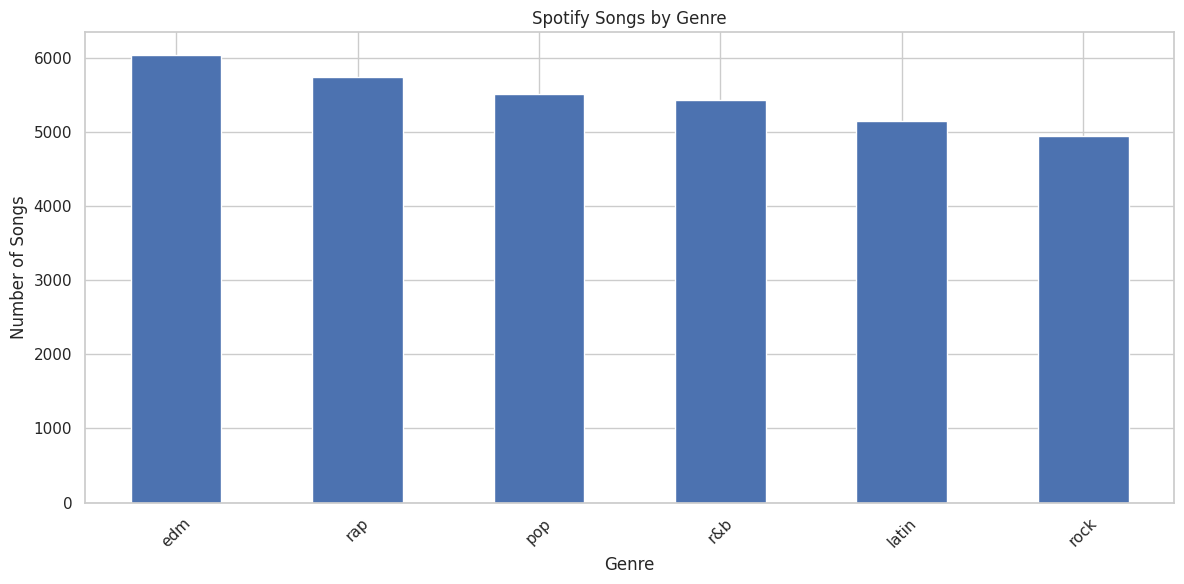

In [10]:
plt.figure(figsize=(12,6))

genre_counts = df["playlist_genre"].value_counts()

genre_counts.plot(kind="bar")

plt.title("Spotify Songs by Genre")

plt.xlabel("Genre")

plt.ylabel("Number of Songs")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

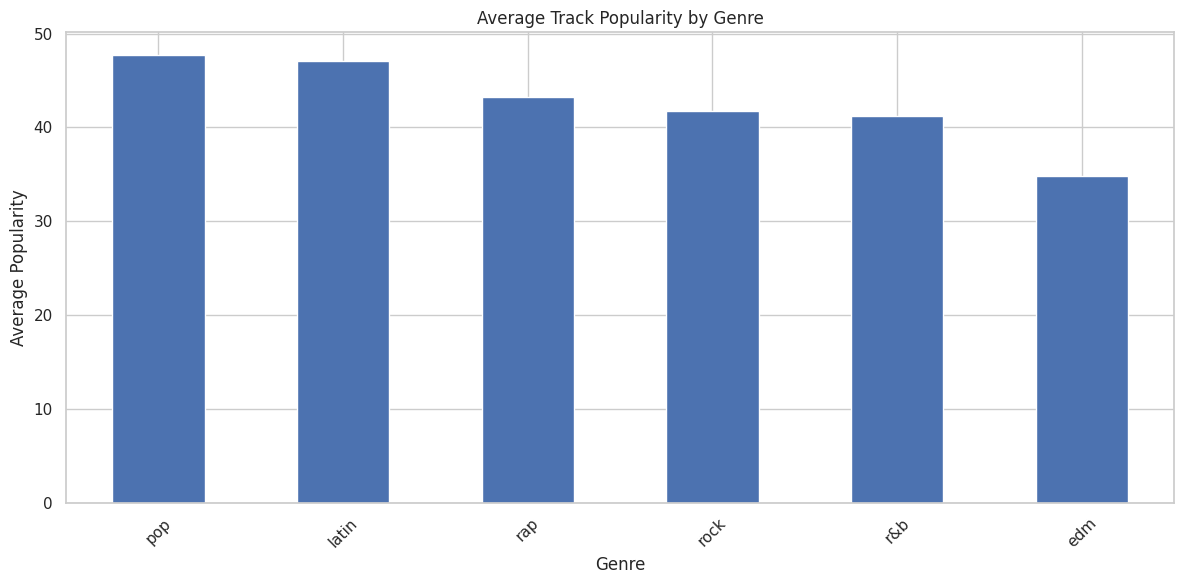

In [11]:
genre_popularity = (
    df.groupby("playlist_genre")["track_popularity"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

genre_popularity.plot(kind="bar")

plt.title("Average Track Popularity by Genre")

plt.xlabel("Genre")

plt.ylabel("Average Popularity")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

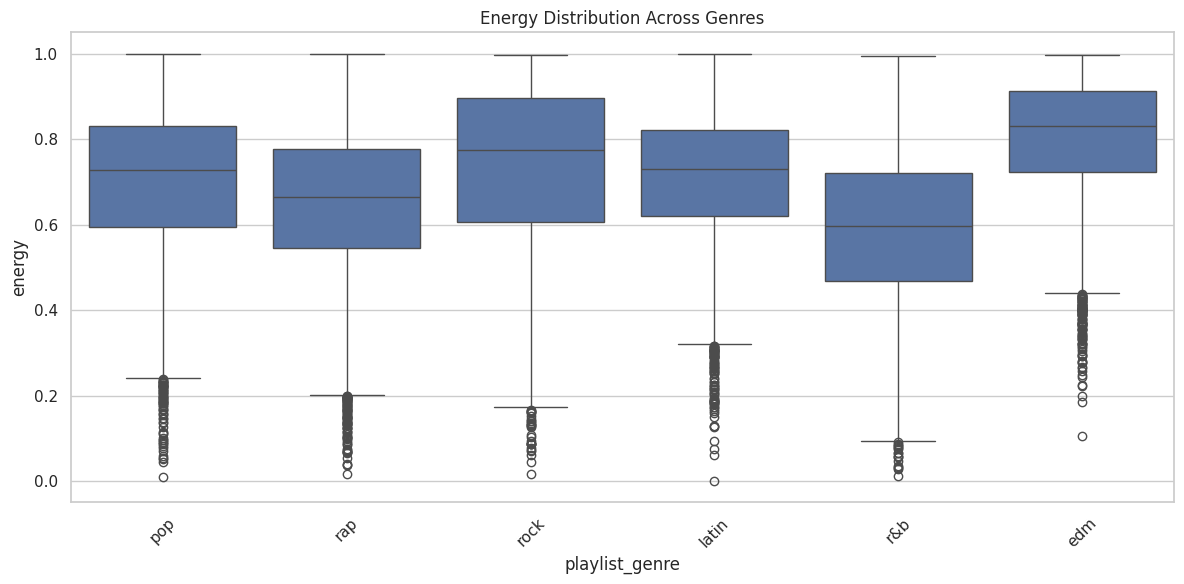

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="playlist_genre",
    y="energy"
)

plt.title("Energy Distribution Across Genres")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

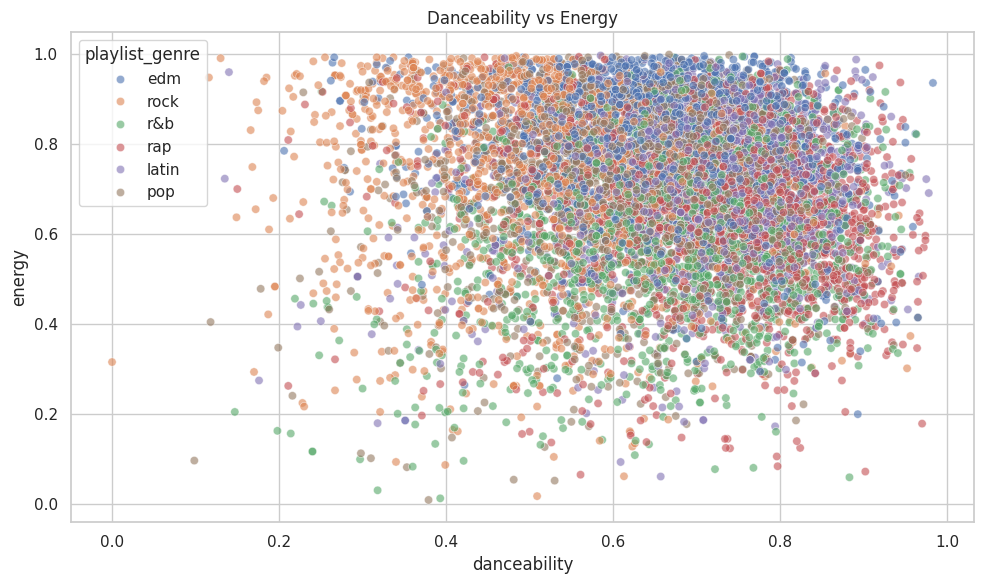

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="danceability",
    y="energy",
    hue="playlist_genre",
    alpha=0.6
)

plt.title("Danceability vs Energy")

plt.tight_layout()

plt.show()

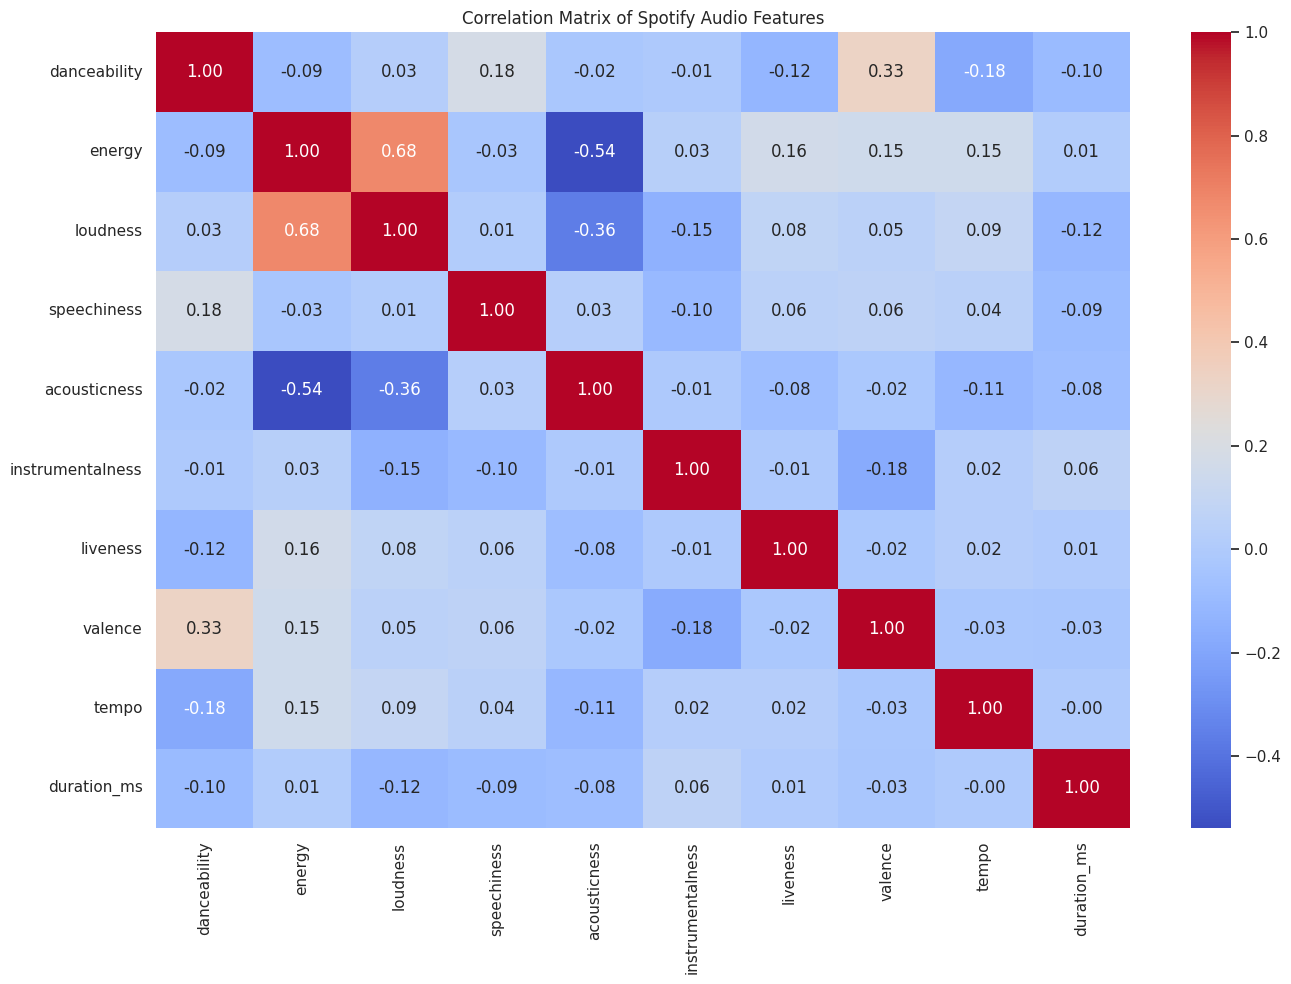

In [14]:
correlation = df[audio_features].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Spotify Audio Features")

plt.tight_layout()

plt.show()

In [15]:
scaler = StandardScaler()

X = scaler.fit_transform(
    df[audio_features]
)

print("Feature Scaling Completed")

print("Feature Matrix Shape:", X.shape)

Feature Scaling Completed
Feature Matrix Shape: (32833, 10)


In [16]:
k_values = range(2, 11)

inertia_values = []

silhouette_values = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    inertia_values.append(
        model.inertia_
    )

    silhouette_values.append(
        silhouette_score(X, labels)
    )

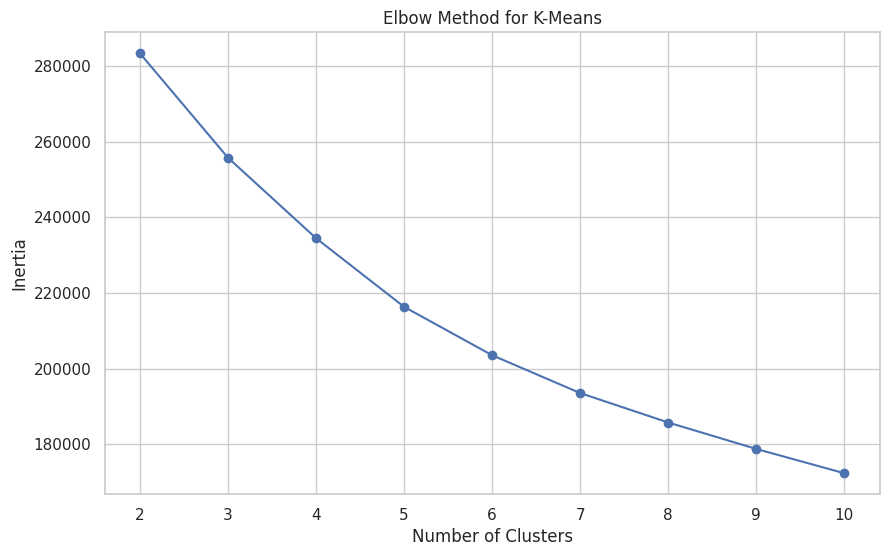

In [17]:
plt.figure(figsize=(10,6))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for K-Means")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

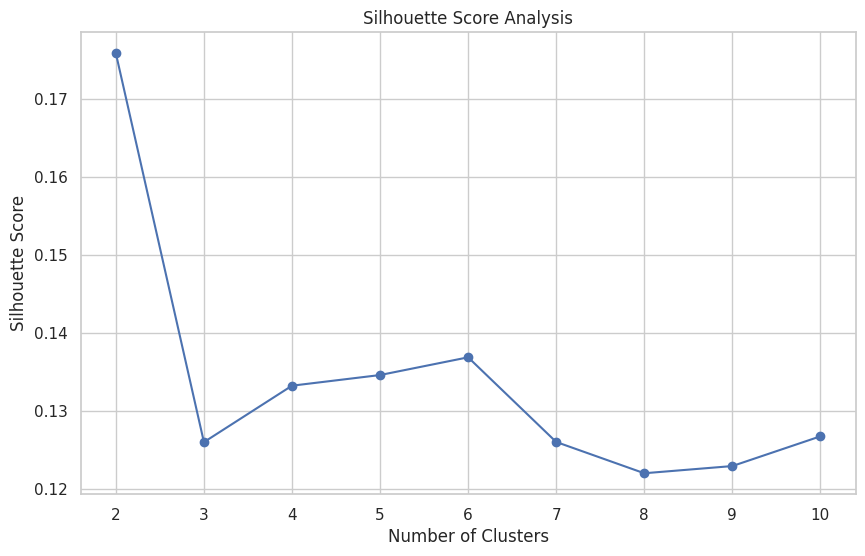

Selected K: 2


In [18]:
plt.figure(figsize=(10,6))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score Analysis")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.show()

best_k = list(k_values)[
    np.argmax(silhouette_values)
]

print("Selected K:", best_k)

In [19]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

print("K-Means Training Completed")

print(
    df["cluster"].value_counts().sort_index()
)

K-Means Training Completed
cluster
0     9684
1    23149
Name: count, dtype: int64


In [20]:
cluster_profile = (
    df.groupby("cluster")[audio_features]
    .mean()
    .round(3)
)

display(cluster_profile)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.660,0.493,-9.694,0.111,0.372,0.104,0.156,0.460,113.328,229638.731
1,0.653,0.785,-5.475,0.105,0.093,0.077,0.204,0.532,124.041,224193.864


In [21]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X)

print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

Explained Variance Ratio: [0.21524068 0.15450781]
Total Explained Variance: 0.369748495958799


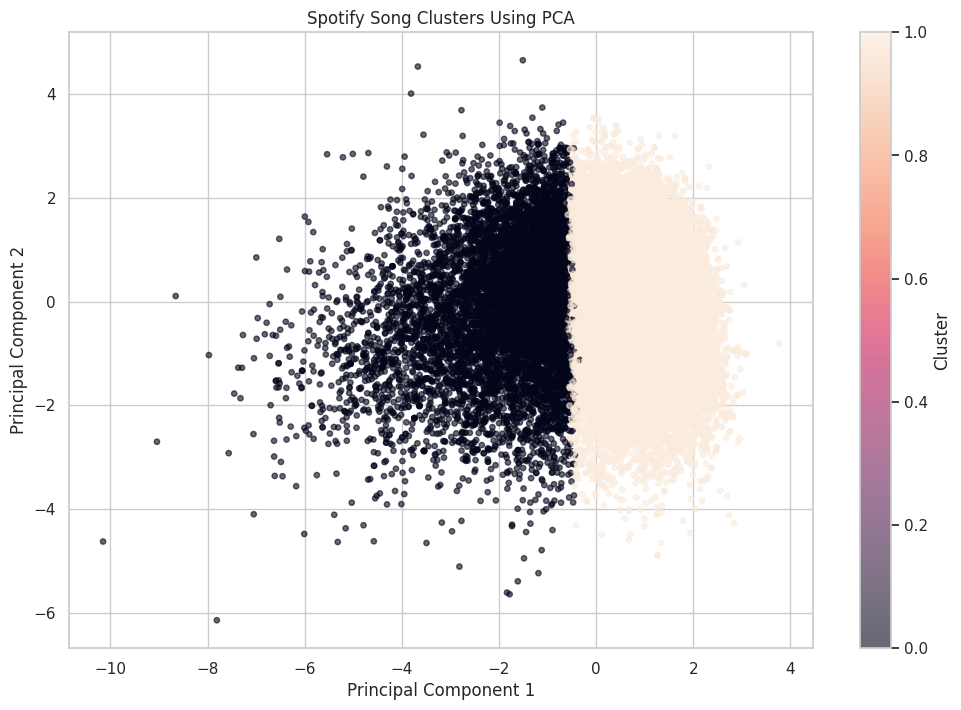

In [22]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster"],
    s=15,
    alpha=0.6
)

plt.title(
    "Spotify Song Clusters Using PCA"
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

In [23]:
labels = df["cluster"]

silhouette = silhouette_score(
    X,
    labels
)

davies_bouldin = davies_bouldin_score(
    X,
    labels
)

calinski = calinski_harabasz_score(
    X,
    labels
)

print("Model Evaluation Results")

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(davies_bouldin, 4)
)

print(
    "Calinski-Harabasz Score:",
    round(calinski, 4)
)

Model Evaluation Results
Silhouette Score: 0.1758
Davies-Bouldin Index: 2.2285
Calinski-Harabasz Score: 5212.1678


In [24]:
genre_cluster = pd.crosstab(
    df["playlist_genre"],
    df["cluster"]
)

display(genre_cluster)

cluster,0,1
playlist_genre,,
edm,661,5382
latin,1311,3844
pop,1388,4119
r&b,2817,2614
rap,2012,3734
rock,1495,3456


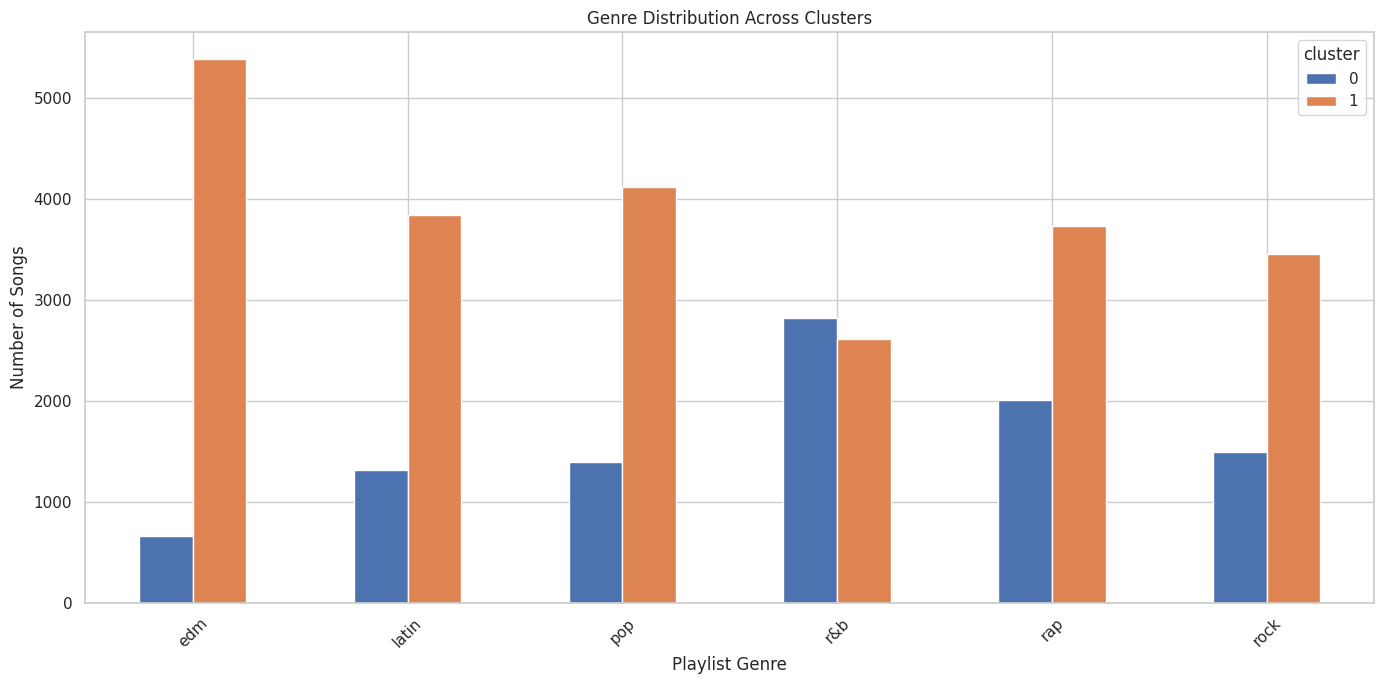

In [25]:
genre_cluster.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title(
    "Genre Distribution Across Clusters"
)

plt.xlabel("Playlist Genre")

plt.ylabel("Number of Songs")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [26]:
playlist_cluster = (
    df.groupby(
        ["playlist_name", "cluster"]
    )
    .size()
    .reset_index(
        name="song_count"
    )
    .sort_values(
        "song_count",
        ascending=False
    )
)

display(
    playlist_cluster.head(20)
)

,playlist_name,cluster,song_count
370,Indie Poptimism,1,264
335,Hard Rock Workout,1,219
271,Fitness Workout Electro | House | Dance | Prog...,1,191
526,Permanent Wave,1,186
652,Southern Hip Hop,1,165
839,post teen pop,1,153
16,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,1,149
136,"Classic Rock 70s 80s 90s, Rock Classics - 70s ...",1,135
168,Dance Pop,1,127
118,Charts 2020 🔥Top 2020🔥Hits 2020🔥Summer 2020🔥Po...,1,125


In [27]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = (
    hierarchical_model.fit_predict(X)
)

hierarchical_silhouette = silhouette_score(
    X,
    hierarchical_labels
)

print(
    "Hierarchical Clustering Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

Hierarchical Clustering Silhouette Score: 0.2638


In [28]:
kmeans_silhouette = silhouette_score(
    X,
    df["cluster"]
)

comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

display(comparison)

,Model,Silhouette Score
0,K-Means,0.175821
1,Hierarchical Clustering,0.263776


In [29]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score,
    davies_bouldin_score
)

from scipy.optimize import linear_sum_assignment

import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

for col in audio_features:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    df[col] = df[col].fillna(
        df[col].median()
    )

scaler = StandardScaler()

X = scaler.fit_transform(
    df[audio_features]
)

print("Feature scaling completed")

Feature scaling completed


In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_true = label_encoder.fit_transform(
    df["playlist_genre"].astype(str)
)

genre_names = label_encoder.classes_

print("Number of Genres:", len(genre_names))

print("Genres:")
print(genre_names)

Number of Genres: 6
Genres:
['edm' 'latin' 'pop' 'r&b' 'rap' 'rock']


In [32]:
number_of_clusters = len(
    np.unique(y_true)
)

kmeans = KMeans(
    n_clusters=number_of_clusters,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

print("K-Means model trained")

K-Means model trained


In [33]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=number_of_clusters,
    linkage="ward"
)

hierarchical_labels = (
    hierarchical_model.fit_predict(X)
)

print("Hierarchical model trained")

Hierarchical model trained


In [34]:
def map_cluster_labels(y_true, cluster_labels):

    confusion = confusion_matrix(
        y_true,
        cluster_labels
    )

    row_ind, col_ind = linear_sum_assignment(
        -confusion
    )

    mapping = {
        cluster: genre
        for genre, cluster in zip(
            row_ind,
            col_ind
        )
    }

    mapped_labels = np.array([
        mapping.get(cluster, -1)
        for cluster in cluster_labels
    ])

    return mapped_labels

In [35]:
kmeans_mapped = map_cluster_labels(
    y_true,
    kmeans_labels
)

hierarchical_mapped = map_cluster_labels(
    y_true,
    hierarchical_labels
)

In [37]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [38]:
results = []

results.append(
    evaluate_model(
        "K-Means",
        y_true,
        kmeans_mapped
    )
)

results.append(
    evaluate_model(
        "Hierarchical Clustering",
        y_true,
        hierarchical_mapped
    )
)

comparison_df = pd.DataFrame(
    results
)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,K-Means,0.323211,0.349978,0.328487,0.309960
1,Hierarchical Clustering,0.291780,0.317467,0.287212,0.273713


In [40]:
percentage_results = comparison_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

percentage_results[metric_columns] = (
    percentage_results[metric_columns] * 100
).round(2)

display(percentage_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,K-Means,32.32,35.00,32.85,31.00
1,Hierarchical Clustering,29.18,31.75,28.72,27.37


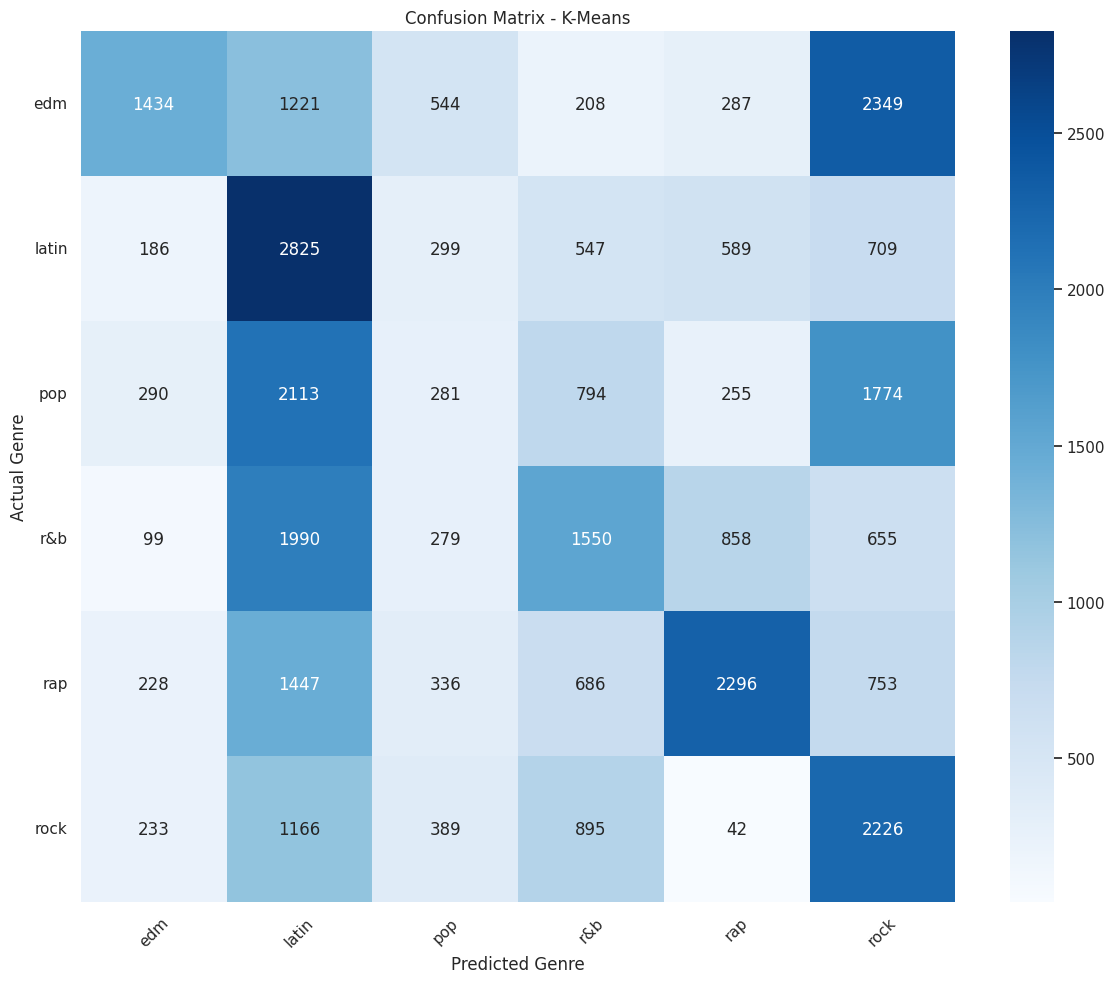

In [41]:
plt.figure(figsize=(12, 10))

cm_kmeans = confusion_matrix(
    y_true,
    kmeans_mapped
)

sns.heatmap(
    cm_kmeans,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=genre_names,
    yticklabels=genre_names
)

plt.title(
    "Confusion Matrix - K-Means"
)

plt.xlabel("Predicted Genre")

plt.ylabel("Actual Genre")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [42]:
print(
    classification_report(
        y_true,
        kmeans_mapped,
        labels=range(len(genre_names)),
        target_names=genre_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         edm       0.58      0.24      0.34      6043
       latin       0.26      0.55      0.35      5155
         pop       0.13      0.05      0.07      5507
         r&b       0.33      0.29      0.31      5431
         rap       0.53      0.40      0.46      5746
        rock       0.26      0.45      0.33      4951

    accuracy                           0.32     32833
   macro avg       0.35      0.33      0.31     32833
weighted avg       0.36      0.32      0.31     32833



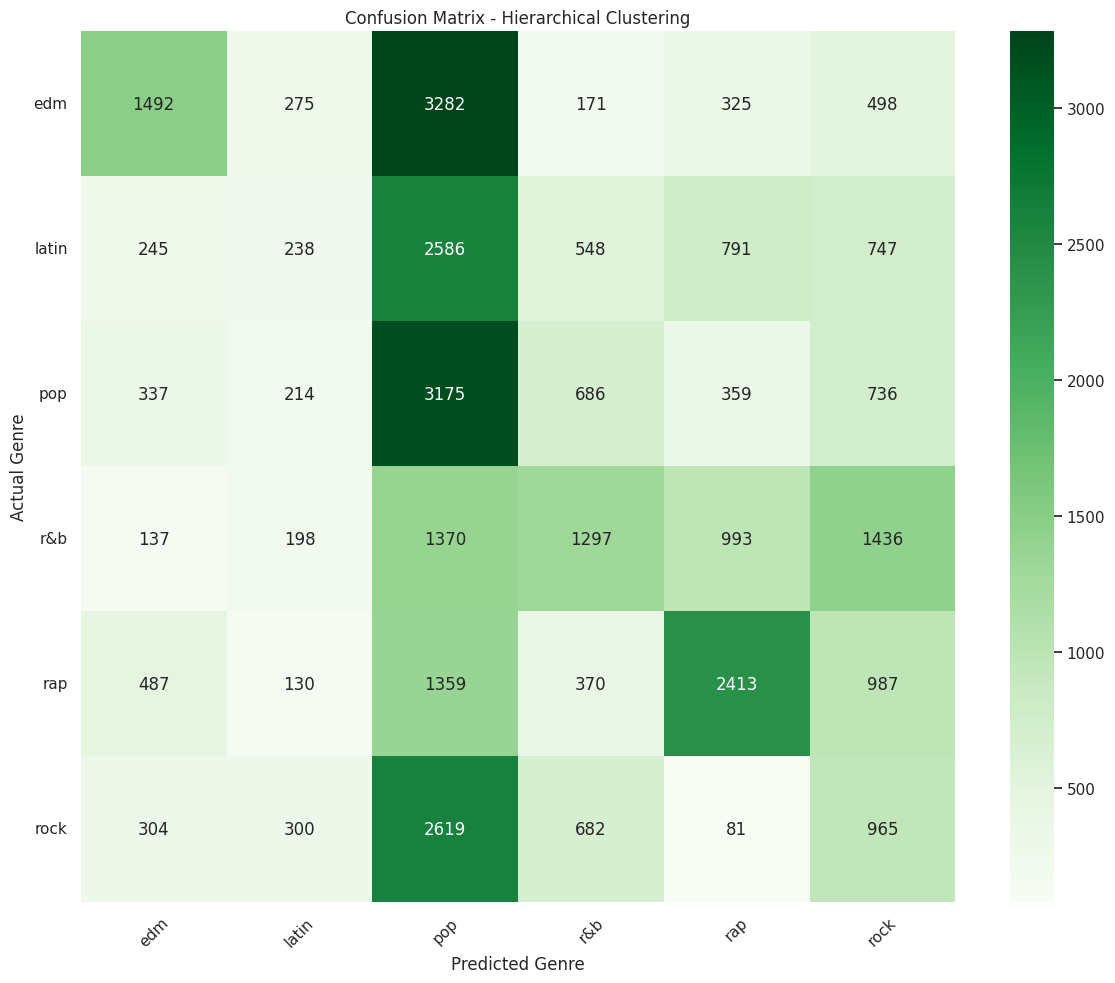

In [43]:
plt.figure(figsize=(12, 10))

cm_hierarchical = confusion_matrix(
    y_true,
    hierarchical_mapped
)

sns.heatmap(
    cm_hierarchical,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=genre_names,
    yticklabels=genre_names
)

plt.title(
    "Confusion Matrix - Hierarchical Clustering"
)

plt.xlabel("Predicted Genre")

plt.ylabel("Actual Genre")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [44]:
print(
    classification_report(
        y_true,
        hierarchical_mapped,
        labels=range(len(genre_names)),
        target_names=genre_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         edm       0.50      0.25      0.33      6043
       latin       0.18      0.05      0.07      5155
         pop       0.22      0.58      0.32      5507
         r&b       0.35      0.24      0.28      5431
         rap       0.49      0.42      0.45      5746
        rock       0.18      0.19      0.19      4951

    accuracy                           0.29     32833
   macro avg       0.32      0.29      0.27     32833
weighted avg       0.33      0.29      0.28     32833



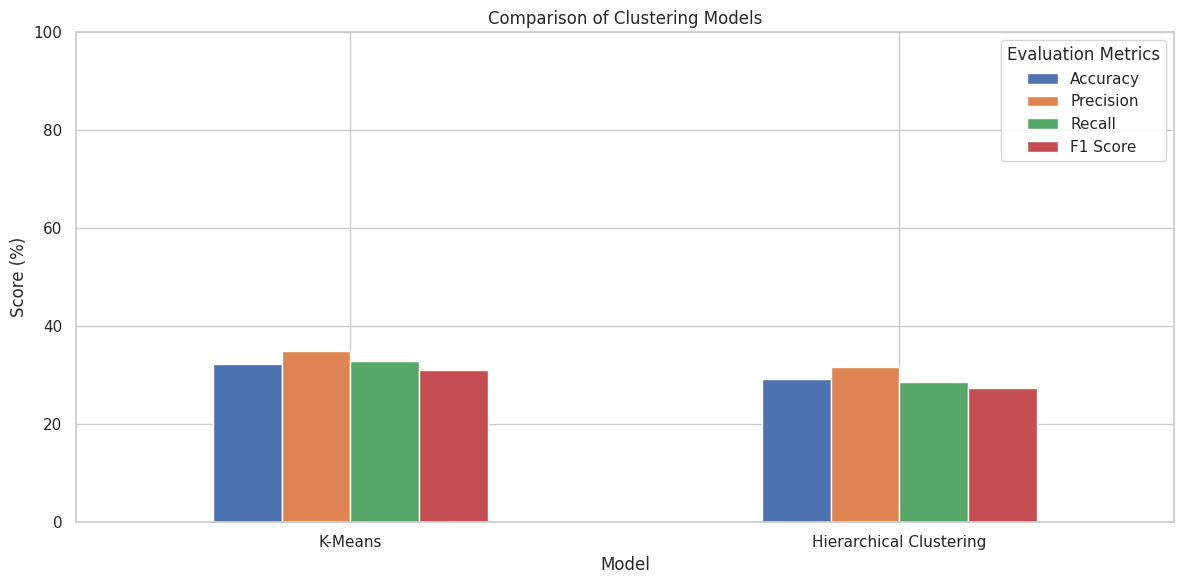

In [45]:
comparison_plot = percentage_results.set_index(
    "Model"
)

comparison_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Comparison of Clustering Models"
)

plt.xlabel("Model")

plt.ylabel("Score (%)")

plt.ylim(0, 100)

plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metrics"
)

plt.tight_layout()

plt.show()

In [46]:
best_model_row = comparison_df.loc[
    comparison_df["F1 Score"].idxmax()
]

print(
    "Best model based on macro F1-score:",
    best_model_row["Model"]
)

print(
    "F1 Score:",
    round(
        best_model_row["F1 Score"],
        4
    )
)

Best model based on macro F1-score: K-Means
F1 Score: 0.31


In [47]:
kmeans_silhouette = silhouette_score(
    X,
    kmeans_labels
)

hierarchical_silhouette = silhouette_score(
    X,
    hierarchical_labels
)

kmeans_db = davies_bouldin_score(
    X,
    kmeans_labels
)

hierarchical_db = davies_bouldin_score(
    X,
    hierarchical_labels
)

clustering_metrics = pd.DataFrame({

    "Model": [
        "K-Means",
        "Hierarchical Clustering"
    ],

    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ],

    "Davies-Bouldin Index": [
        kmeans_db,
        hierarchical_db
    ]
})

display(clustering_metrics)

,Model,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.136877,1.735013
1,Hierarchical Clustering,0.092794,2.153030


In [48]:
from sklearn.neighbors import NearestNeighbors

In [49]:
recommendation_scaler = StandardScaler()

recommendation_X = (
    recommendation_scaler.fit_transform(
        df[audio_features]
    )
)

nn_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=11
)

nn_model.fit(
    recommendation_X
)

print("Recommendation model trained")

Recommendation model trained


In [50]:
def recommend_songs(
    track_name,
    number_of_recommendations=5
):

    matches = df[
        df["track_name"]
        .astype(str)
        .str.contains(
            str(track_name),
            case=False,
            na=False
        )
    ]

    if matches.empty:

        print(
            "Song not found:",
            track_name
        )

        return pd.DataFrame()

    selected_index = matches.index[0]

    row_position = df.index.get_loc(
        selected_index
    )

    selected_cluster = (
        kmeans_labels[row_position]
    )

    distances, indices = (
        nn_model.kneighbors(
            recommendation_X[
                row_position
            ].reshape(1, -1),
            n_neighbors=50
        )
    )

    candidate_positions = []

    for distance, position in zip(
        distances[0],
        indices[0]
    ):

        if position == row_position:
            continue

        if kmeans_labels[position] == selected_cluster:

            candidate_positions.append(
                (distance, position)
            )

        if len(candidate_positions) >= number_of_recommendations:
            break

    if len(candidate_positions) < number_of_recommendations:

        print(
            "Not enough songs in the same cluster. "
            "Returning the closest available songs."
        )

        candidate_positions = [
            (distance, position)
            for distance, position in zip(
                distances[0],
                indices[0]
            )
            if position != row_position
        ][:number_of_recommendations]

    selected_positions = [
        position
        for distance, position in candidate_positions
    ]

    recommendations = df.iloc[
        selected_positions
    ][
        [
            "track_name",
            "track_artist",
            "playlist_genre",
            "playlist_name",
            "track_popularity",
            "cluster"
        ]
    ].copy()

    return recommendations

In [51]:
example_track = df[
    "track_name"
].dropna().iloc[0]

print(
    "Selected Track:",
    example_track
)

display(
    recommend_songs(
        example_track,
        5
    )
)

Selected Track: I Don't Care (with Justin Bieber) - Loud Luxury Remix
Song not found: I Don't Care (with Justin Bieber) - Loud Luxury Remix


""


In [53]:
song_name = input(
    "Enter a song name: "
)

display(
    recommend_songs(
        song_name,
        5
    )
)

Enter a song name: Kygo


,track_name,track_artist,playlist_genre,playlist_name,track_popularity,cluster
16300,Younger - Kygo Remix,Seinabo Sey,latin,Tropical House,66,0
17374,Younger - Kygo Remix,Seinabo Sey,latin,EDM TROPICAL,57,0
22007,We Are to Be,Chymamusique,r&b,urban contemporary,6,0
31960,Love Is Gone - Original Extended,David Guetta,edm,Electro/Progressive/Club House,12,1
3721,Miami 82 - Kygo Remix,Syn Cole,pop,ElectroPop,59,0


In [54]:
def recommendation_coverage(
    number_of_samples=100,
    recommendations_per_song=5
):

    sample_indices = np.random.choice(
        len(df),
        size=min(number_of_samples, len(df)),
        replace=False
    )

    total_recommendations = 0

    for index in sample_indices:

        distances, indices = (
            nn_model.kneighbors(
                recommendation_X[index].reshape(1, -1),
                n_neighbors=recommendations_per_song + 1
            )
        )

        total_recommendations += len(
            indices[0][1:]
        )

    coverage = (
        total_recommendations /
        len(sample_indices)
    )

    return coverage


print(
    "Average recommendations per song:",
    recommendation_coverage()
)

Average recommendations per song: 5.0


In [3]:
%%writefile spotify_clustering.py

Writing spotify_clustering.py


In [9]:
%%writefile requirements.txt

numpy
pandas
matplotlib
seaborn
scikit-learn
scipy
openpyxl
jupyter

Overwriting requirements.txt


In [5]:
import getpass
import subprocess

username = "Raghavendra582"
repository = "Spotify-Genre-Segmentation"

token = getpass.getpass("Enter your GitHub Personal Access Token: ")

repo_url = (
    f"https://{username}:{token}"
    f"@github.com/{username}/{repository}.git"
)

!git config --global user.name "Raghavendra582"
!git config --global user.email "your-email@example.com"

!git clone {repo_url} github_repo

Enter your GitHub Personal Access Token: ··········
Cloning into 'github_repo'...


In [6]:
!cp spotify_clustering.py github_repo/
!cp requirements.txt github_repo/

%cd github_repo

/content/github_repo


In [11]:
!git add spotify_clustering.py requirements.txt
!git commit -m "Add complete Spotify Genre Segmentation"
!git push origin main

[main 088d9c6] Add complete Spotify Genre Segmentation
 1 file changed, 4 insertions(+)
To https://github.com/Raghavendra582/Spotify-Genre-Segmentation.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/Raghavendra582/Spotify-Genre-Segmentation.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.
